# Data Analysis Activity: Revisiting Galton's Height Study
Al Jay Lan ALAMIN | aalamin@ictp.it

In this worksheet, we study the data of Galton on the heights of parents and their children. We explore the use of `matplotlib` and `pandas` packages for this activity.

---

## Preliminaries

In [1]:
#Import libraries
import numpy as np #Do math
import matplotlib.pyplot as plt #Plotting
import pandas as pd #Data manipulation
from scipy.stats import pearsonr #Correlation
from scipy.stats import linregress #Linear regression

# For LaTeX font
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

In [2]:
# read csv file and create copy of dataframe (for safety T.T)
d = pd.read_csv('galton-height.tab',sep='\t')
df = d.copy()

# prints first 5 rows of the dataframe
d.head()

,family,father,mother,gender,height,kids,male,female
0,1,78.5,67.0,M,73.2,4,1.0,0.0
1,1,78.5,67.0,F,69.2,4,0.0,1.0
2,1,78.5,67.0,F,69.0,4,0.0,1.0
3,1,78.5,67.0,F,69.0,4,0.0,1.0
4,2,75.5,66.5,M,73.5,4,1.0,0.0


In [3]:
# prints information about dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   family  898 non-null    str    
 1   father  898 non-null    float64
 2   mother  898 non-null    float64
 3   gender  898 non-null    str    
 4   height  898 non-null    float64
 5   kids    898 non-null    int64  
 6   male    898 non-null    float64
 7   female  898 non-null    float64
dtypes: float64(5), int64(1), str(2)
memory usage: 59.3 KB


Based on the results of the first five rows and the info from the dataset, each row on the dataset corresponds to one child. 

The columns provide data for each of the child:

| column | data type | intepretation |
|--- | --- | --- |
| family | `str` | index/name of family the child belongs to |
| father | `float` | height of the father of the child |
| mother | `float` | height of the mother of the child|
| gender | `str` | `M` or `F` = gender of the child |
| height | `float` | height of the child |
| kids | `int` | number of kids for the family the child belongs to |
| male | `int` | checks if child is MALE (`male == 1 <=> gender == M`)|
| female | `int` | checks if child is FEMALE (`female == 1 <=> gender == F`) |


In the following codeblocks, we familiarize ourself with the dataset and compute relevant quantities, as well as explore the `matplotlib` and `pandas` libraries. We use these results when we perform our linear regressions and compute for conditional probabilities.

Since each row corresponds to one child, the total number of children `M` is just the number of rows. For the number of distinct parents, assuming that no two families share the a mother or a father, we can count the number of families and then double this number to count the total number of parents.

We perform this computation below to count the number of children and the number of families in the dataset.

In [4]:
# counts the number of rows = number of children
M = df['height'].count() 
# counts unique number of families = half of number of parents
Mp = len(df['family'].unique()) * 2 

# alternative soln using groupby
# Mp = len(df[['family', 'height']].groupby('family')['family']) * 2

# prints results
print(f'Number of children: {M}')
print(f'Number of parents: {Mp}')

Number of children: 898
Number of parents: 394


Next, we compute for the means and standard errors for the heights of the mothers, fathers, and children (sons and daughters separately), as well as compute for the ration $k = \mu_{\text{father}}/\mu_{\text{mother}}.$

Note that in the calculation of the means and standard errors for the parents' heights, we use the filtered dataframe ``df_parents`` so that we do not overcount families where there the parents have more children.

In [5]:
# avoids multiple counting for families with many children
df_parents = df[['family','father','mother']].groupby("family").first()

# calculates mean height of parents using df_parents to avoid multiple counting
mu_mother = df_parents['mother'].mean()
mu_father = df_parents['father'].mean()

# calculates mean height of children, sons, and daughters
mu_children = df['height'].mean()
mu_son = df[df['male'] == 1]['height'].mean()
mu_daughter = df[df['female'] == 1]['height'].mean()

# solves for k
k = mu_father / mu_mother

# prints results
print(f'mu_father = {mu_father:.4f}')
print(f'mu_mother= {mu_mother:.4f}')
print(f'mu_children = {mu_children:.4f}')
print(f'mu_son = {mu_son:.4f}')
print(f'mu_daughter = {mu_daughter:.4f}')
print(f'k = {k:.4f}')


mu_father = 69.3492
mu_mother= 63.9843
mu_children = 66.7607
mu_son = 69.2288
mu_daughter = 64.1102
k = 1.0838


In [6]:
# calculates standard deviation of parents (still using parents dataframe to avoid multiple counting)
std_father = df_parents['father'].std()
std_mother = df_parents['mother'].std()

# calculates standard deviation of children, sons, and daughters
std_children = df['height'].std()
std_son = df[df['male'] == 1]['height'].std()
std_daughter = df[df['female'] == 1]['height'].std()

# prints results
print(f'std_father = {std_father:.4f}')
print(f'std_mother= {std_mother:.4f}')
print(f'std_children = {std_children:.4f}')
print(f'std_son = {std_son:.4f}')
print(f'std_daughter = {std_daughter:.4f}')


std_father = 2.6220
std_mother= 2.3556
std_children = 3.5829
std_son = 2.6316
std_daughter = 2.3703


Next, we compute for the midparent heights: $$h_p = \frac{1}{2} \left(h_\text{mother} + h_\text{father}\right),$$ include it in the dataframe, and compute for the respective means and standard deviation.

Then, we solve for the "deviates", i.e. how each datapoint differs from the mean, for both (mid)parents and children.

In [7]:
# calculates the midparent height and its mean
df['midparent'] = (df['father'] + df['mother'])/2
mu_midparent = df['midparent'].mean()

# calculates the deviates of children and midparent heights from their means
df['yc'] = df['height'] - mu_children
df['yp'] = df['midparent'] - mu_midparent

We use `matplotlib` to make a generate scatterplots of 
1. the parents deviates against the number of families (i.e. half of the number of parents), 
2. the children deviates against the number of children, and
3. the children deviates against the parent deviates (note here that we use the original dataframe for the midparent deviates to match the dimension of children deviates).

We collect these scatterplots into a plot (with subplots) as shown below.

Text(0, 0.5, 'children deviates')

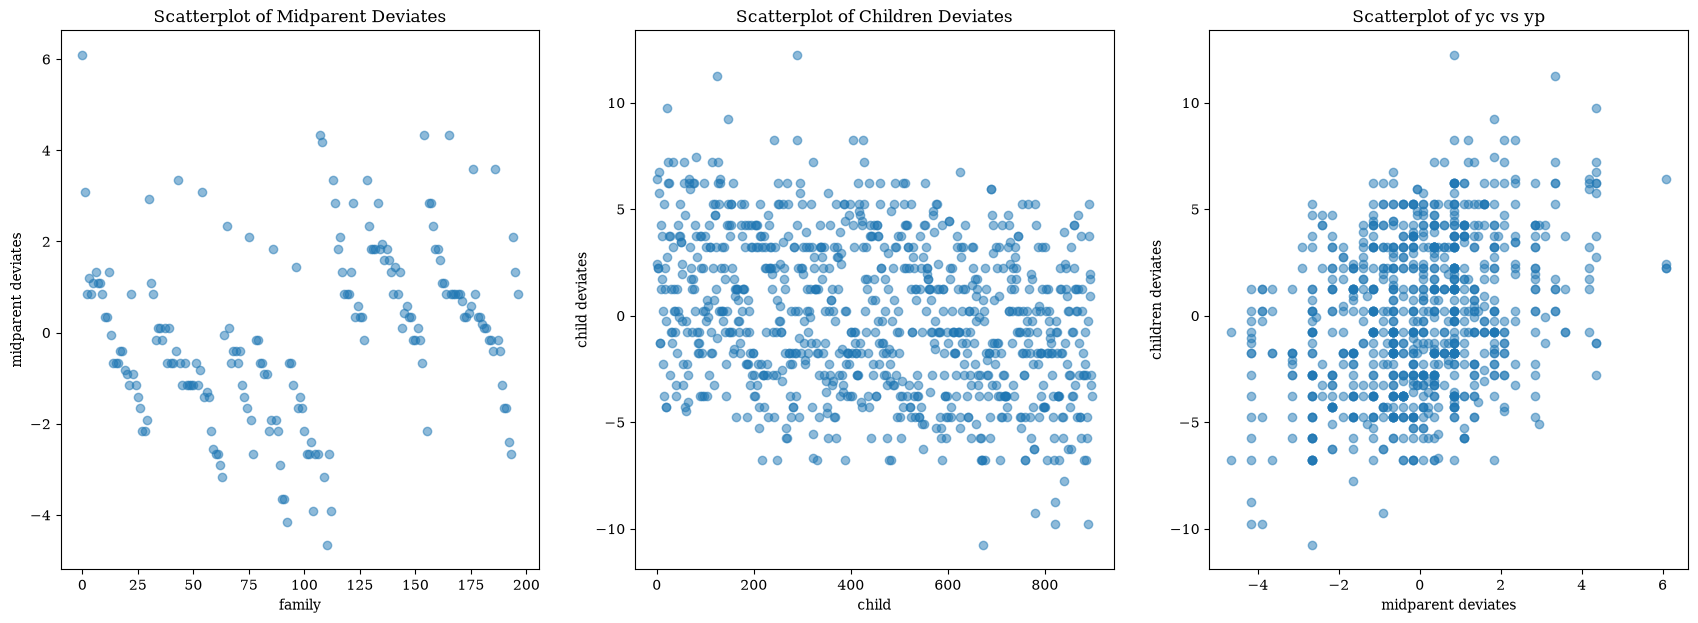

In [8]:
# Plot data
fig = plt.figure(figsize = (21, 7))
yp_parents = df[['family', 'yp']].groupby('family').first()

plt.subplot(131)
dummy = np.arange(0, Mp/2, 1)
plt.title("Scatterplot of Midparent Deviates")
plt.scatter(dummy,yp_parents['yp'],alpha=0.5)
plt.xlabel('family')
plt.ylabel('midparent deviates')

dummy = np.arange(0, M, 1)
# plt.title("Scatterplot of Midparent Deviates")
# plt.scatter(dummy,df['yp'],alpha=0.3)

plt.subplot(132)
dummy = np.arange(0, M, 1)
plt.title("Scatterplot of Children Deviates")
plt.scatter(dummy,df['yc'],alpha=0.5)
plt.xlabel('child')
plt.ylabel('child deviates')

plt.subplot(133)
plt.title("Scatterplot of yc vs yp")
plt.scatter(df['yp'],df['yc'],alpha=0.5)
plt.xlabel('midparent deviates')
plt.ylabel('children deviates')

We also create a splot containing the (normalized) histograms for the midparent and children deviates.

Here, we note that the histograms obeys a Gaussian distribution. The legend is shown in the upper right (best position according to python[?]).

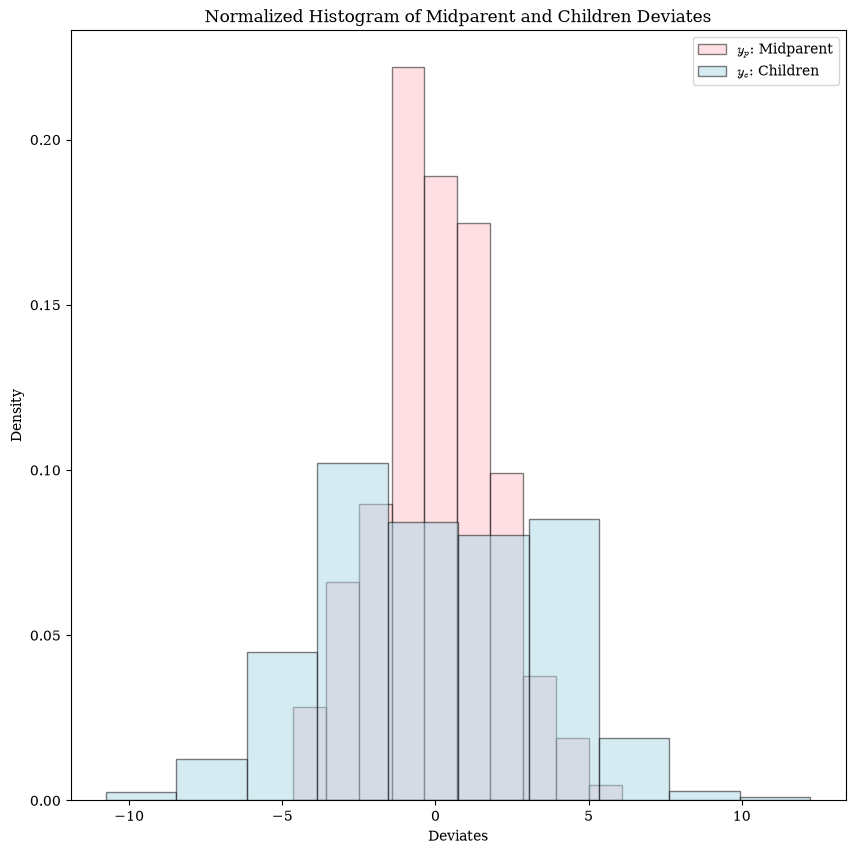

In [9]:
fig = plt.figure(figsize = (10,10))
plt.title("Normalized Histogram of Midparent and Children Deviates")
plt.xlabel('Deviates')
plt.ylabel('Density')
plt.hist(yp_parents['yp'], color='pink', edgecolor='black', alpha=0.5, label = '$y_p$: Midparent', density=True)
plt.hist(df['yc'], color='lightblue', edgecolor='black', alpha = 0.5, label = '$y_c$: Children', density=True)
plt.legend()

Finally, we compute the Pearson's correlation between the parent and children deviates.

In [10]:
corr, pval = pearsonr(df['yc'],df['yp'])
print("R-squared:", corr**2)

R-squared: 0.10697736868526182


## Regression to the Mean

In this section, we explore more on the relationship between parent and children deviates.

We introduce three pre-processing techniques in analyzing linear regression:
1. using original data
2. applying Galton's sex-correction factor of 1.08 for female heights
3. using deviation scores

Then, we repeat the same linear regression using binned parental data across the three pre-processing techniques.

For each of the techniques, we call `lingress` and obtain the slope, intercept, and Pearson's $r^2.$

In [11]:
slope, intercept, r_value, p_value, std_err = linregress(df['yp'],df['yc']) #Calculate linear regression
print("Slope:", slope,  
    "\nIntercept:", intercept, 
    "\nR-squared:", r_value**2, 
    "\nP-value:", p_value)

Slope: 0.6692588951325453 
Intercept: 9.408122686793577e-17 
R-squared: 0.10697736868526178 
P-value: 7.824483180937209e-24


In [12]:
df['mother_adj'] = df['mother']*1.08
df['height_adj'] = np.where(df['gender'] == 'F', df['height']*1.08, df['height'])

df['midparent_adj'] = (df['father'] + df['mother_adj'])/2

mu_children_adj = df['height_adj'].mean()
mu_midparent_adj = df[['family','midparent_adj']].groupby('family').first().mean()['midparent_adj']

df['yc_adj'] = df['height_adj'] - mu_children_adj
df['yp_adj'] = df['midparent_adj'] - mu_midparent_adj

slope_adj, intercept_adj, r_value_adj, p_value_adj, std_err_adj = linregress(df['yp_adj'],df['yc_adj']) #Calculate linear regression
print("Slope:", slope_adj,  
    "\nIntercept:", intercept_adj, 
    "\nR-squared:", r_value_adj**2, 
    "\nP-value:", p_value_adj)

Slope: 0.7290561951755337 
Intercept: 0.0030001726100361355 
R-squared: 0.26063547741254084 
P-value: 9.224505060799051e-61


In [13]:
# Deviation Scores
df['zc'] = np.where(df['gender'] == 'M', 
                    (df['height'] - mu_son)/std_son, 
                    (df['height'] - mu_daughter)/std_daughter)

df['zp'] = (((df['mother'] - mu_mother)/std_mother) + ((df['father'] - mu_father)/std_father))/2

slope_z, intercept_z, r_value_z, p_value_z, std_err_z = linregress(df['zp'],df['zc']) #Calculate linear regression

print("Slope:", slope_z,  
    "\nIntercept:", intercept_z, 
    "\nR-squared:", r_value_z**2, 
    "\nP-value:", p_value_z)


Slope: 0.7237441157522289 
Intercept: 0.0006783450115351983 
R-squared: 0.2599264734758939 
P-value: 1.4191056602761237e-60


Using the above, we generate a scatterplot of the three scenarios with their corresponding linear fits.

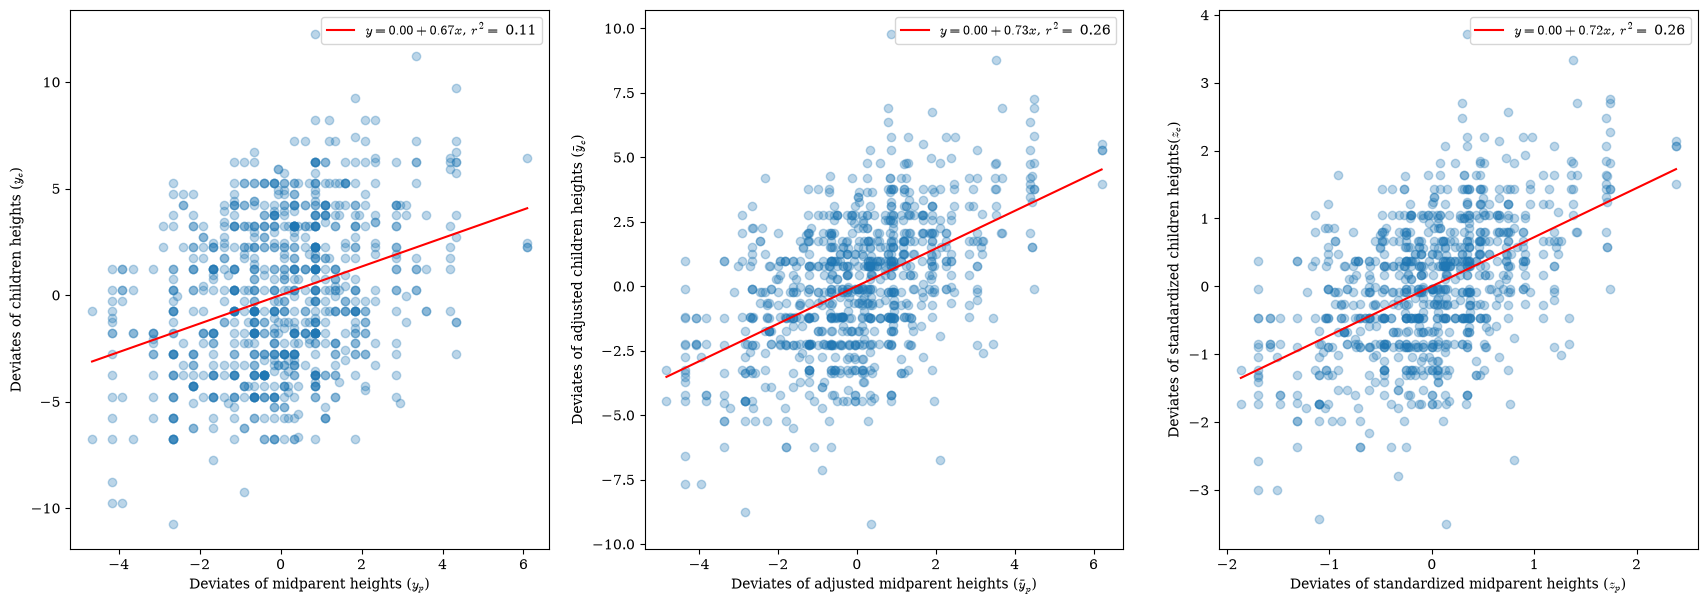

In [14]:
fig = plt.figure(figsize=(21,7))

plt.subplot(131)
x = np.linspace(df['yp'].min(), df['yp'].max(), 100)
plt.scatter(df['yp'],df['yc'], alpha = 0.3)
plt.plot(x, intercept + x * slope, color = 'red', label = f'$y = {intercept:.2f} + {slope:.2f}x$, $r^2 =$ {r_value**2:.2f}')
plt.xlabel('Deviates of midparent heights ($y_p$)')
plt.ylabel('Deviates of children heights ($y_c$)')
plt.legend()

plt.subplot(132)
x = np.linspace(df['yp_adj'].min(), df['yp_adj'].max(), 100)
plt.scatter(df['yp_adj'], df['yc_adj'], alpha = 0.3)
plt.plot(x, intercept_adj + x * slope_adj, color = 'red', label = f'$y = {intercept_adj:.2f} + {slope_adj:.2f}x$, $r^2 =$ {r_value_adj**2:.2f}')
plt.xlabel('Deviates of adjusted midparent heights ($\\tilde y_p$)')
plt.ylabel('Deviates of adjusted children heights ($\\tilde y_c$)')
plt.legend()

plt.subplot(133)
x = np.linspace(df['zp'].min(), df['zp'].max(), 100)
plt.scatter(df['zp'], df['zc'], alpha = 0.3)
plt.plot(x, intercept_z + x * slope_z, color = 'red', label = f'$y = {intercept_z:.2f} + {slope_z:.2f}x$, $r^2 =$ {r_value_z**2:.2f}')
plt.xlabel('Deviates of standardized midparent heights ($z_p$)')
plt.ylabel('Deviates of standardized children heights($z_c$)')
plt.legend()

Across the three preprocessing regimes, the slope of the original children vs. midparent deviates data is close to 2/3 ($m \approx 0.67$), while that of the adjusted and standardized slopes are higher ($m \approx 0.72$). Therefore, although the slope remains positive, Galton's result of two-thirds is somewhat reliant on the preprocessing.

On Pearson's $r^2$ value, we see a much larger discrepancy on the values. Specifically, if we look at the Pearson correlation coefficient $r = \sqrt{r^2}$ (positive since sloping up), the strength of the linear correlation between the two datasets is not robust with respect to preprocessing.

In the following codeblocks, we explore a binning strategy and consider less points in our regression, in an effor to plausibly reduce noise in the data.

In [15]:
# For binned data
num = 10
yp_min = df['yp'].min()
yp_max = df['yp'].max()

delta_y = (yp_max - yp_min) / num

bins = []

for yp in df['yp']:
    for k in range(num):
        left = yp_min + (k * delta_y)
        right = yp_min + ((k+1) * delta_y)

        if k < num - 1 and left <= yp < right:
            bins.append(k)
        elif k == num - 1 and left <= yp <= right:
            bins.append(k)
            
df['bin'] = bins

groups = df.groupby('bin')
binned = groups[['yp', 'yc']].mean()
binned['n'] = groups.size()

binned.head()

,yp,yc,n
bin,,,
0,-4.046561,-2.615863,29
1,-2.769951,-2.205973,53
2,-1.936069,-1.086300,82
3,-0.821851,-0.490979,208
4,0.171276,-0.071438,214


In [16]:
# For binned data (adjusted)
yp_min = df['yp_adj'].min()
yp_max = df['yp_adj'].max()

delta_y = (yp_max - yp_min) / num

bins = []

for yp in df['yp_adj']:
    for k in range(num):
        left = yp_min + (k * delta_y)
        right = yp_min + ((k+1) * delta_y)

        if k < num - 1 and left <= yp < right:
            bins.append(k)
        elif k == num - 1 and left <= yp <= right:
            bins.append(k)
            
df['bin_adj'] = bins

groups = df.groupby('bin_adj')
binned_adj = groups[['yp_adj', 'yc_adj']].mean()
binned_adj['n_adj'] = groups.size()

In [17]:
# For binned data (zc vs. zp)
zp_min = df['zp'].min()
zp_max = df['zp'].max()

delta_z = (zp_max - zp_min) / num

bins = []

for zp in df['zp']:
    for k in range(num):
        left = zp_min + (k * delta_z)
        right = zp_min + ((k+1) * delta_z)

        if k < num - 1 and left <= zp < right:
            bins.append(k)
        elif k == num - 1 and left <= zp <= zp_max:
            bins.append(k)
            
df['bin_z'] = bins

groups = df.groupby('bin_z')
binned_z = groups[['zp','zc']].mean()
binned_z['n_z'] = groups.size()

In [18]:
slopeb, interceptb, r_valueb, p_valueb, std_errb = linregress(binned['yp'],binned['yc']) #Calculate linear regression
print("Slope:", slopeb,  
    "\nIntercept:", interceptb, 
    "\nR-squared:", r_valueb**2, 
    "\nP-value:", p_valueb,
    "\n")

slope_adjb, intercept_adjb, r_value_adjb, p_value_adjb, std_err_adjb = linregress(binned_adj['yp_adj'],binned_adj['yc_adj']) #Calculate linear regression
print("Slope:", slope_adjb,  
    "\nIntercept:", intercept_adjb, 
    "\nR-squared:", r_value_adjb**2, 
    "\nP-value:", p_value_adjb,
    "\n")

slope_zb, intercept_zb, r_value_zb, p_value_zb, std_err_zb = linregress(binned_z['zp'],binned_z['zc']) #Calculate linear regression
print("Slope:", slope_zb,  
    "\nIntercept:", intercept_zb, 
    "\nR-squared:", r_value_zb**2, 
    "\nP-value:", p_value_zb, 
    "\n")

Slope: 0.6648903024260927 
Intercept: 0.013533522334590264 
R-squared: 0.9644664751656816 
P-value: 4.4226162486075367e-07 

Slope: 0.7686116757181314 
Intercept: 0.10911163240851196 
R-squared: 0.9868925757756916 
P-value: 8.11366875009696e-09 

Slope: 0.7679332901111463 
Intercept: 0.04377560311049178 
R-squared: 0.9864513592172482 
P-value: 9.264207842376262e-09 



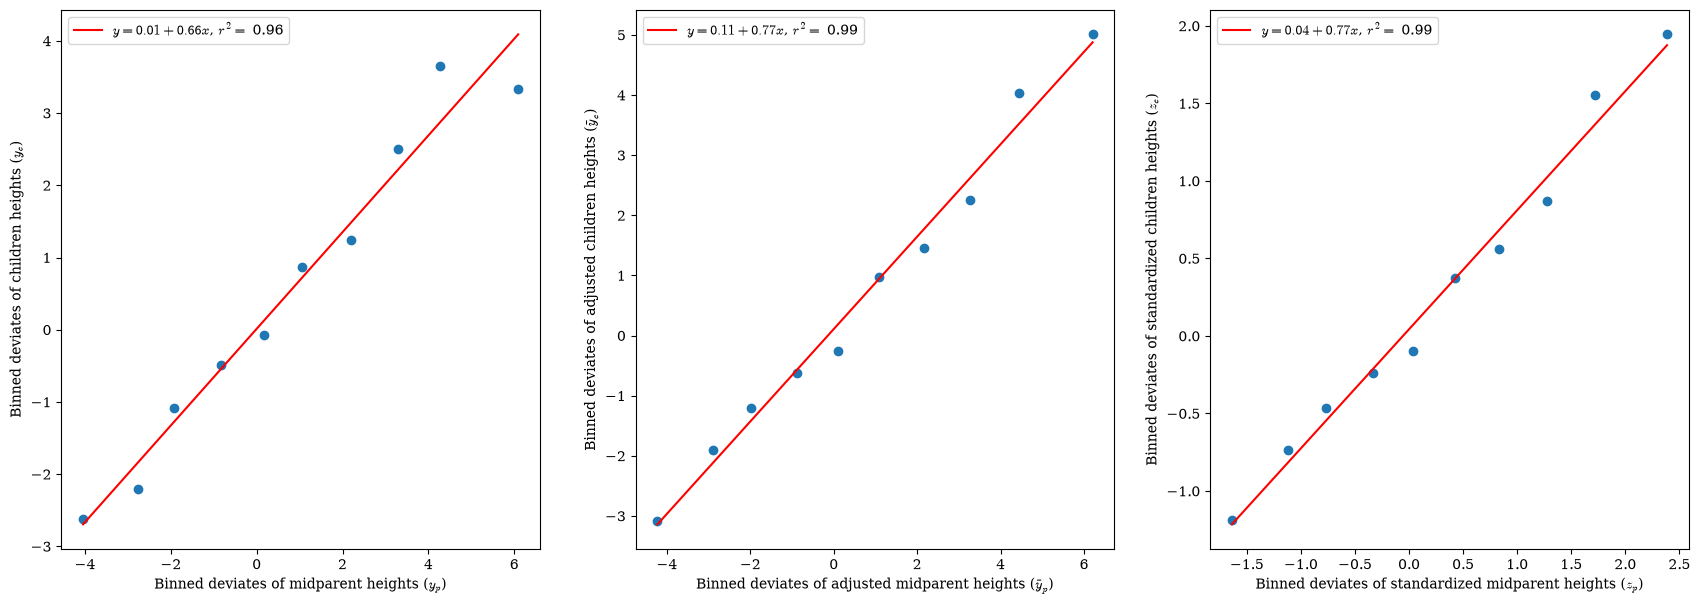

In [19]:
fig = plt.figure(figsize=(21, 7))

plt.subplot(131)
x = np.linspace(binned['yp'].min(), binned['yp'].max(), 100)
plt.scatter(binned['yp'],binned['yc'], alpha = 1)
plt.plot(x, interceptb + x * slope, color = 'red', label = f'$y = {interceptb:.2f} + {slopeb:.2f}x$, $r^2 =$ {r_valueb**2:.2f}')
plt.xlabel('Binned deviates of midparent heights ($y_p$)')
plt.ylabel('Binned deviates of children heights ($y_c$)')
plt.legend()

plt.subplot(132)
x = np.linspace(binned_adj['yp_adj'].min(), binned_adj['yp_adj'].max(), 100)
plt.scatter(binned_adj['yp_adj'], binned_adj['yc_adj'], alpha = 1)
plt.plot(x, intercept_adjb + x * slope_adjb, color = 'red', label = f'$y = {intercept_adjb:.2f} + {slope_adjb:.2f}x$, $r^2 =$ {r_value_adjb**2:.2f}')
plt.xlabel('Binned deviates of adjusted midparent heights ($\\tilde y_p$)')
plt.ylabel('Binned deviates of adjusted children heights ($\\tilde y_c$)')
plt.legend()

plt.subplot(133)
x = np.linspace(binned_z['zp'].min(), binned_z['zp'].max(), 100)
plt.scatter(binned_z['zp'], binned_z['zc'], alpha = 1)
plt.plot(x, intercept_zb + x * slope_zb, color = 'red', label = f'$y = {intercept_zb:.2f} + {slope_zb:.2f}x$, $r^2 =$ {r_value_zb**2:.2f}')
plt.xlabel('Binned deviates of standardized midparent heights ($z_p$)')
plt.ylabel('Binned deviates of standardized children heights ($z_c$)')
plt.legend()

In this analysis, we obtain similar slopes and $y$-intercepts between the binned data and their respective complete data for the original, adjusted, and standardized data. This also results in a much higher Pearson's $r^2$ and as such, a higher correlation coefficient $r$ (very close to 1) implying a strong linear relationship between the children deviates and midparent deviates.

However, a caveat here is that the binning data essentially forces this relationship by removing a significant number of points. That is, a 10-point dataset is not comparable to >800-point dataset. Therefore, although binning the data reduces the scatter, this does not imply a strong linear relationship across all the datapoints.

In conclusion, although the result of Galton is robust in the sense that the trend is positive and somewhat close to 2/3 (for the original dataset), we find that preprocessing of data by either incorporating gender-based adjustments and standardization resulted in a numerically different but similar result. Specifically, the Pearson correlation coefficient has a more significant difference among the preprocessing techniques altering the stability on the linear relationship of the data. Therefore, although the data indeed shows a positive slope between children deviates and midparent deviates, the exact slope and strength of this linear relationship may depend on the preprocessing technique applied on the dataset.

## On the Asymmetry of Conditional Probabilities

In this section, we explore the asymmetry of having "extreme" heights in our dataset across the three pre-processing methods, i.e. with the original heights, the adjusted heights for females, and the standardized heights.



In [20]:
# Conditional Probabilities

diff = []
for alpha in np.linspace(1,10,1000):
    # print(f'alpha = {alpha:.3f}')
    ext_c = sum(df['yc'].abs() > alpha)
    ext_p = sum(df['yp'].abs() > alpha)

    ext_both = sum((df['yc'].abs() > alpha) & (df['yp'].abs() > alpha)) # row by row comparison

    if ext_both == 0:
        # print('oops')
        continue

    prob_ext_c = ext_c / len(df['yc'])
    prob_ext_p = ext_p / len(df['yp'])

    prob_ext_p_given_ext_c = ext_both / ext_c
    prob_ext_c_given_ext_p = ext_both / ext_p

    # print(f'Prob(child extreme | parent extreme) = {prob_ext_c_given_ext_p:.4f}')
    # print(f'Prob(parent extreme | child extreme) = {prob_ext_p_given_ext_c:.4f}')

    diff.append(prob_ext_c_given_ext_p - prob_ext_p_given_ext_c)
    
print(f'Average Difference = {np.mean(diff):.4f}, Std deviation = {np.std(diff):.4f}')

Average Difference = 0.3242, Std deviation = 0.0604


In [21]:
diff = []

for alpha in np.linspace(1,10, 1000):
    # print(f'alpha = {alpha:.3f}')
    ext_c = sum(df['yc_adj'].abs() > alpha)
    ext_p = sum(df['yp_adj'].abs() > alpha)

    ext_both = sum((df['yc_adj'].abs() > alpha) & (df['yp_adj'].abs() > alpha)) # row by row comparison

    if ext_both == 0:
        # print('oops')
        continue
    
    prob_ext_c = ext_c / len(df['yc_adj'])
    prob_ext_p = ext_p / len(df['yp_adj'])

    prob_ext_p_given_ext_c = ext_both / ext_c
    prob_ext_c_given_ext_p = ext_both / ext_p

    # print(f'Prob(child extreme | parent extreme) = {prob_ext_c_given_ext_p:.4f}')
    # print(f'Prob(parent extreme | child extreme) = {prob_ext_p_given_ext_c:.4f}')

    diff.append(prob_ext_c_given_ext_p - prob_ext_p_given_ext_c)

print(f'Average Difference = {np.mean(diff):.4f}, Std deviation = {np.std(diff):.4f}')

Average Difference = 0.3185, Std deviation = 0.1395


In [22]:
diff = []

for alpha in np.linspace(0.1,1,1000):
    # print(f'alpha = {alpha:.3f}')
    ext_c = sum(df['zc'].abs() > alpha)
    ext_p = sum(df['zp'].abs() > alpha)

    ext_both = sum((df['zc'].abs() > alpha) & (df['zp'].abs() > alpha)) # row by row comparison

    prob_ext_c = ext_c / len(df['zc'])
    prob_ext_p = ext_p / len(df['zp'])

    prob_ext_p_given_ext_c = ext_both / ext_c
    prob_ext_c_given_ext_p = ext_both / ext_p

    # print(f'Prob(child extreme | parent extreme) = {prob_ext_c_given_ext_p:.4f}')
    # print(f'Prob(parent extreme | child extreme) = {prob_ext_p_given_ext_c:.4f}')

    diff.append(prob_ext_c_given_ext_p - prob_ext_p_given_ext_c)

print(f'Average Difference = {np.mean(diff):.4f}, Std deviation = {np.std(diff):.4f}')

Average Difference = 0.2054, Std deviation = 0.0510


For each of the chosen values of $\alpha,$ we see that $P(\text{child extreme} \mid \text{parent extreme}) > P(\text{parent extreme} \mid \text{child extreme}).$ 

Moreover, this holds regardless of the data preprocessing performed on the data. However, when we measure the magnitude of this asymmetry through the average difference of $P(\text{child extreme} \mid \text{parent extreme}) - P(\text{parent extreme} \mid \text{child extreme})$ (always positive) over different values of $\alpha,$ the standardized data gives a *lower* difference.

This is because the meaning of $\alpha$ for the case of the original dataset, adjusted dataset, and standardized dataset change. Indeed, for the original dataset and adjusted dataset, the column for heights (adjusted or not) are in the units of inches so that when we have the extreme condition ($|y| > \alpha$,) this implies that the height in inches is greater than $\alpha = 2$ in for example. However,, for the case of the standardized dataset, the meaning of $\alpha$ changes from "height in inches" to "number of standard deviations". Therefore, the definition of what it means to be extreme changes. Indeed, having an absolute deviation greater than 2 *inches* is very different from having an absolute deviation greater than 2 *standard deviations*. As a result, the preprocessing changes the magnitude of the asymmetry of the conditional probability.

In conclusion, we say that the asymmetry of conditional probabilities as a property is stable, but changes in magnitude dependinghis asymmetry remains stable among all preprocessing techniques. This asymmetry comes from the fact that the denominator for the two conditional probabilities are different. In empirical data, this suggests irreversibility of directional inference due to the way conditional probability is defined.

---
Last Edited: 08 October 2026, 11:57